In [47]:
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image

In [48]:


def make_silhouette_sampler(png_path, extent=1.25, alpha_threshold=10, seed=0):
    rng = np.random.default_rng(seed)

    img = Image.open(png_path).convert("RGBA")
    arr = np.array(img)

    alpha = arr[..., 3]
    mask = alpha > alpha_threshold          # silhouette = non-transparent pixels

    ys, xs = np.where(mask)
    coords = np.stack([xs, ys], axis=1)

    H, W = alpha.shape

    def sample_p_data(n=1):
        idx = rng.integers(0, coords.shape[0], size=n)
        pix = coords[idx].astype(np.float32)

        x = (pix[:, 0] / (W - 1)) * 2 * extent - extent
        y = (1.0 - pix[:, 1] / (H - 1)) * 2 * extent - extent  # flip y
        pts = np.stack([x, y], axis=1)
        return pts[0] if n == 1 else pts

    return sample_p_data


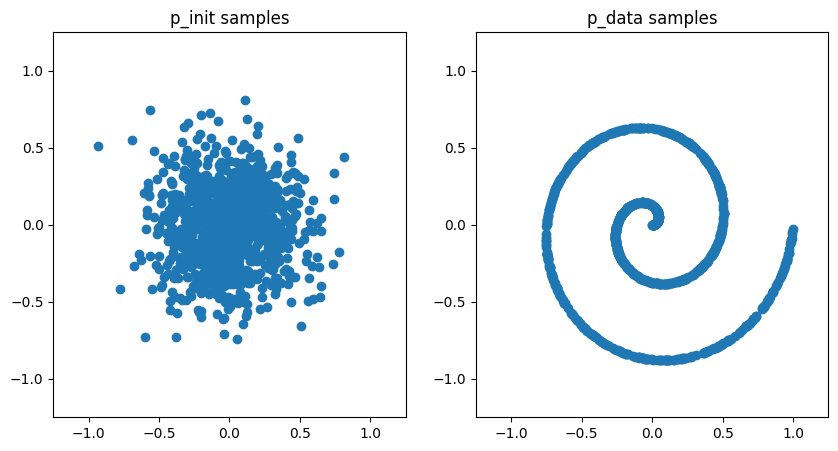

In [9]:
# define p_init and p_data

# 2d gaussian
def sample_p_init():
    return 0.25 * np.random.randn(2)

# checkerboard
'''
def sample_p_data():
    
    
    while True:
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        
        i = math.floor((2*x))
        j = math.floor((2*y))
    
        if (i + j) % 2 == 0:
            return np.array([x, y])
'''

# spiral
def sample_p_data():
    theta = np.random.uniform(0, 4*np.pi) 
    r = theta / (4*np.pi)                
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.array([x, y])


#sample_p_data = make_silhouette_sampler("cat.png", extent=1.15)



samples_init = np.array([sample_p_init() for _ in range(1000)])
samples_data = np.array([sample_p_data() for _ in range(1000)])

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("p_init samples")
plt.scatter(samples_init[:,0], samples_init[:,1])
plt.xlim(-1.25,1.25)
plt.ylim(-1.25,1.25)

plt.subplot(1,2,2)
plt.title("p_data samples")
plt.scatter(samples_data[:,0], samples_data[:,1])
plt.xlim(-1.25,1.25)
plt.ylim(-1.25,1.25)
plt.show()

In [10]:
def sample_marginal_path(t, n_samples = 1000):
    
    z = np.array([sample_p_data() for _ in range(n_samples)])
    x0 = np.array([sample_p_init() for _ in range(n_samples)])
    
    x_t = (1 - t) * x0 + t * z # interpolate
    
    return x_t
    

In [11]:
def sample_conditional_path(t,z, n_samples = 1000):
    
     x0 = np.array([sample_p_init() for _ in range(n_samples)])
     
     x_t = (1 - t) * x0 + t * z # interpolate
    
     return x_t
    
    


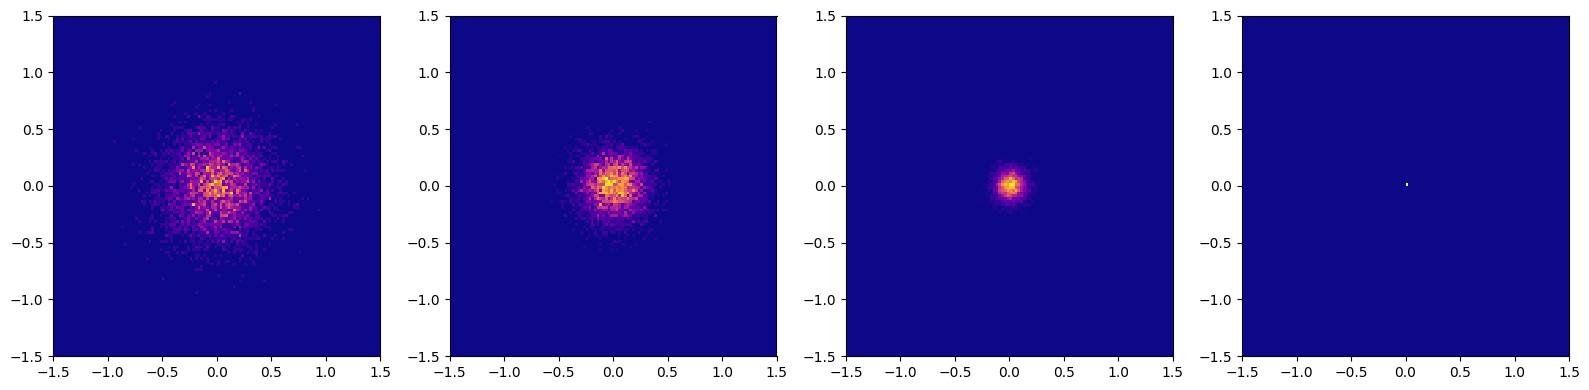

In [12]:
times = [0.0, 0.33, 0.67, 1.0]

z = sample_p_data()

fig, axes = plt.subplots(1, len(times), figsize=(16,4))
for i, t in enumerate(times):
    
    x_t = sample_conditional_path(t, z, n_samples=5000)
    
    axes[i].hist2d(x_t[:,0], x_t[:,1], bins=120, range=[[-1.5, 1.5], [-1.5, 1.5]], cmap='plasma')

plt.tight_layout()
plt.show()

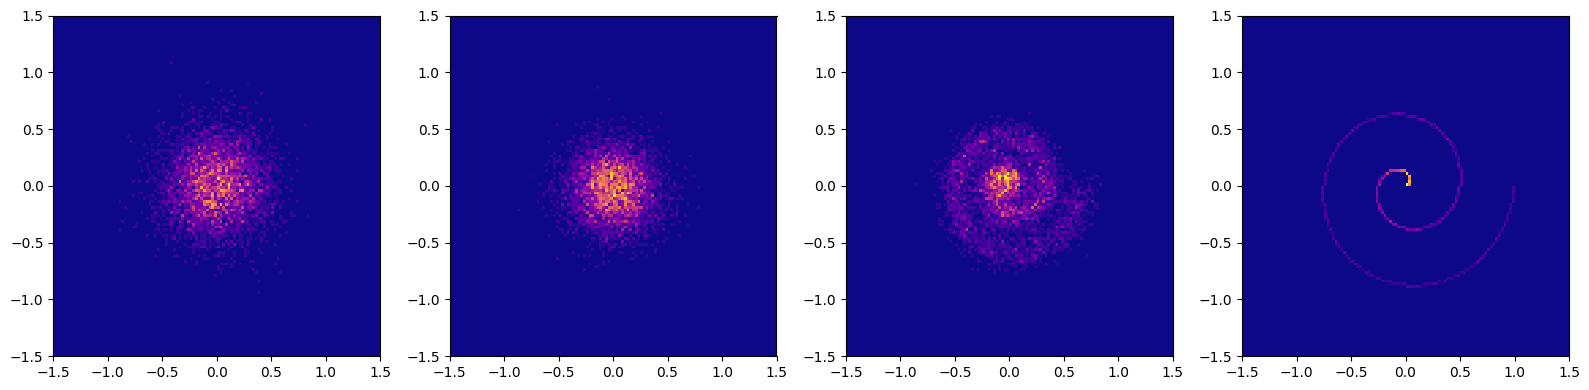

In [13]:


times = [0.0, 0.33, 0.67, 1.0]

z = sample_p_data()

fig, axes = plt.subplots(1, len(times), figsize=(16,4))
for i, t in enumerate(times):
    
    x_t = sample_marginal_path(t, n_samples=5000)
    
    axes[i].hist2d(x_t[:,0], x_t[:,1], bins=120, range=[[-1.5, 1.5], [-1.5, 1.5]], cmap='plasma')

plt.tight_layout()
plt.show()
    
    




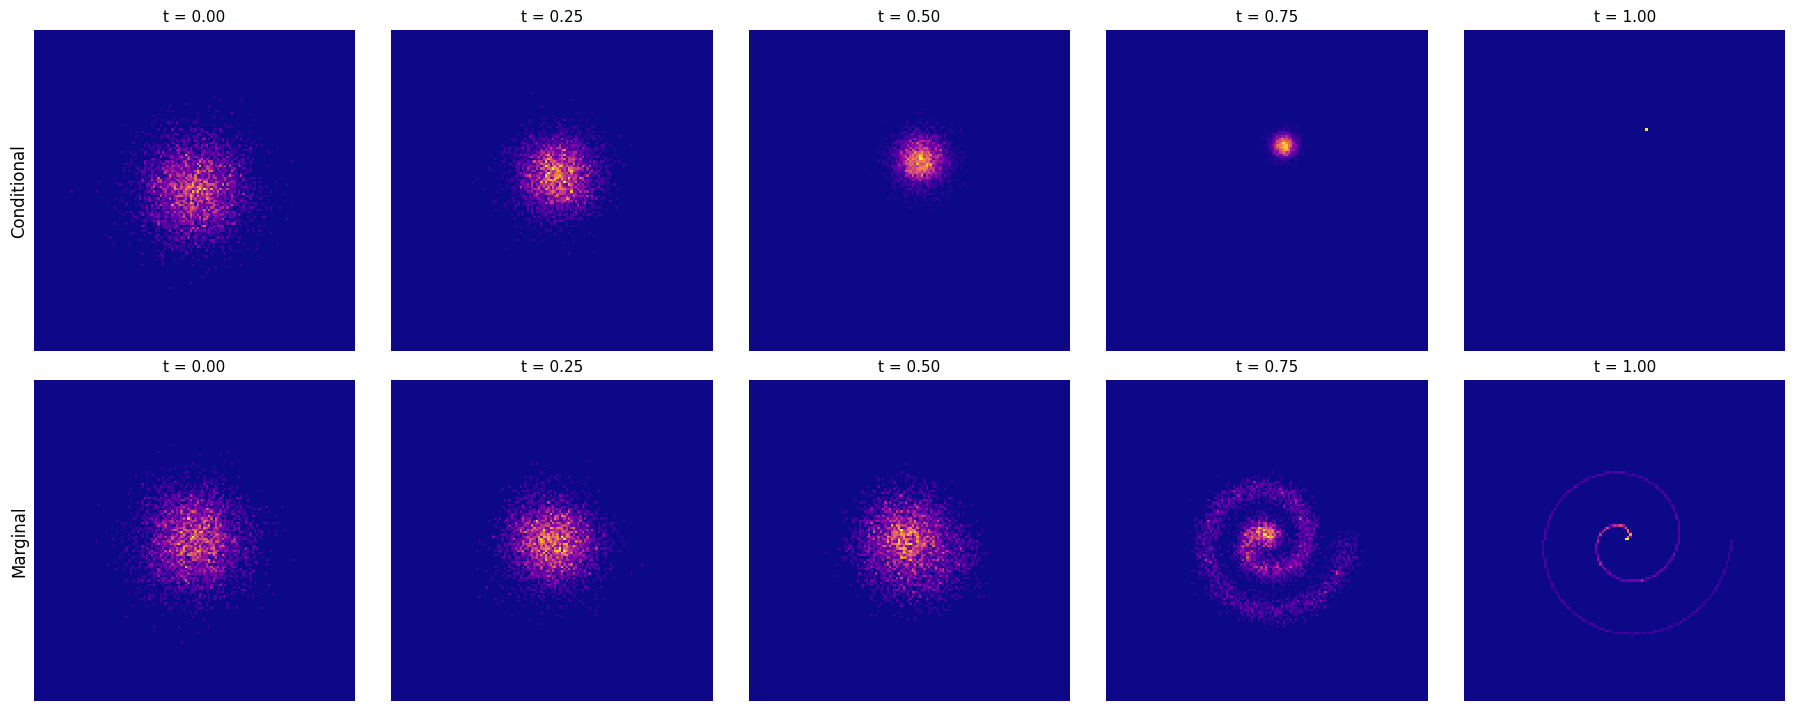

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 5 time points
times = [0.0, 0.25, 0.5, 0.75, 1.0]

BINS = 140
RANGE = [[-1.5, 1.5], [-1.5, 1.5]]
CMAP = "plasma"
N_SAMPLES = 5000

# fixed endpoint for conditional path
z = sample_p_data()

fig, axes = plt.subplots(2, len(times), figsize=(18, 7), constrained_layout=True)

for j, t in enumerate(times):
    # --- Conditional (top row) ---
    x_t_cond = sample_conditional_path(t, z, n_samples=N_SAMPLES)
    axes[0, j].hist2d(x_t_cond[:, 0], x_t_cond[:, 1], bins=BINS, range=RANGE, cmap=CMAP)
    axes[0, j].set_title(f"t = {t:.2f}", fontsize=11)
    axes[0, j].set_aspect("equal", adjustable="box")
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

    # --- Marginal (bottom row) ---
    x_t_marg = sample_marginal_path(t, n_samples=N_SAMPLES)
    axes[1, j].hist2d(x_t_marg[:, 0], x_t_marg[:, 1], bins=BINS, range=RANGE, cmap=CMAP)
    axes[1, j].set_title(f"t = {t:.2f}", fontsize=11)
    axes[1, j].set_aspect("equal", adjustable="box")
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])


axes[0, 0].set_ylabel("Conditional", fontsize=12)
axes[1, 0].set_ylabel("Marginal", fontsize=12)


for ax in axes.ravel():
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.show()
